## The Electronic Nose Dataset for Plant Oil with Different Compositions

In [33]:
import os
import pandas as pd
from pathlib import Path

# Define the dataset path
dataset_path = Path('/Users/momthu/Documents/duhoc/Hungary/elte/research/oil/dataset_Oils')

# Get all oil type folders
oil_folders = sorted([d for d in dataset_path.iterdir() if d.is_dir()])
print(f"Found {len(oil_folders)} oil type folders:")
for folder in oil_folders:
    print(f"  - {folder.name}")


Found 19 oil type folders:
  - CO
  - COO
  - COO1
  - COO2
  - COO3
  - COO4
  - COO5
  - RO0
  - RO1
  - RO2
  - RO3
  - RO4
  - RO5
  - SO0
  - SO1
  - SO2
  - SO3
  - SO4
  - SO5


In [34]:
# Check columns consistency across all files
columns_dict = {}
total_files = 0
files_with_issues = []

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    print(f"\n{oil_folder.name}: {len(txt_files)} files")
    
    if txt_files:
        # Read first file to get columns
        first_file = txt_files[0]
        df = pd.read_csv(first_file)
        columns = tuple(df.columns)
        
        if columns not in columns_dict:
            columns_dict[columns] = []
        
        columns_dict[columns].append((oil_folder.name, first_file.name, len(txt_files)))
        print(f"  Columns: {list(df.columns)}")
        print(f"  Shape: {df.shape}")
        total_files += len(txt_files)
        
        # Check if all files in this folder have the same columns
        for txt_file in txt_files[1:]:
            df_check = pd.read_csv(txt_file)
            if tuple(df_check.columns) != columns:
                files_with_issues.append((oil_folder.name, txt_file.name))

print(f"\n{'='*60}")
print(f"TOTAL FILES: {total_files}")
print(f"{'='*60}")


CO: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO1: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO2: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO3: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO4: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

COO5: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

RO0: 70 files
  Columns: ['Time [s]', 'TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
  Shape: (150, 7)

RO1: 70 fil

In [35]:
# Summary of columns consistency
print("\n" + "="*70)
print("SUMMARY OF COLUMN CONSISTENCY ANALYSIS")
print("="*70)

if len(columns_dict) == 1:
    print("\n✓ ALL FILES HAVE CONSISTENT COLUMNS!")
    print(f"\nTotal unique column structure(s): {len(columns_dict)}")
    
    # Display the single column structure
    for columns, oil_info in columns_dict.items():
        print(f"\nColumn names ({len(columns)} columns):")
        for i, col in enumerate(columns, 1):
            print(f"  {i}. {col}")
        
        print(f"\nFiles using this structure ({len(oil_info)} oil types):")
        total_files_with_structure = 0
        for oil_type, first_file, num_files in oil_info:
            print(f"  - {oil_type}: {num_files} files")
            total_files_with_structure += num_files
        print(f"\n  Total files: {total_files_with_structure}")
else:
    print(f"\n✗ FOUND {len(columns_dict)} DIFFERENT COLUMN STRUCTURES!")
    print("\nColumn structures:")
    for i, (columns, oil_info) in enumerate(columns_dict.items(), 1):
        print(f"\n  Structure {i}: {columns}")
        print(f"  Used in: {[info[0] for info in oil_info]}")

if files_with_issues:
    print(f"\n⚠ WARNING: Found {len(files_with_issues)} files with inconsistent columns")
    print("Files with issues:")
    for oil_type, filename in files_with_issues[:10]:  # Show first 10
        print(f"  - {oil_type}/{filename}")
    if len(files_with_issues) > 10:
        print(f"  ... and {len(files_with_issues) - 10} more")
else:
    print("\n✓ All files within each oil type have consistent columns")

print("\n" + "="*70)


SUMMARY OF COLUMN CONSISTENCY ANALYSIS

✓ ALL FILES HAVE CONSISTENT COLUMNS!

Total unique column structure(s): 1

Column names (7 columns):
  1. Time [s]
  2. TGS2620
  3. TGS2602
  4. TGS2603
  5. TGS2610
  6. TGS2611
  7. TGS2600

Files using this structure (19 oil types):
  - CO: 70 files
  - COO: 70 files
  - COO1: 70 files
  - COO2: 70 files
  - COO3: 70 files
  - COO4: 70 files
  - COO5: 70 files
  - RO0: 70 files
  - RO1: 70 files
  - RO2: 70 files
  - RO3: 70 files
  - RO4: 70 files
  - RO5: 70 files
  - SO0: 70 files
  - SO1: 70 files
  - SO2: 70 files
  - SO3: 70 files
  - SO4: 70 files
  - SO5: 70 files

  Total files: 1330

✓ All files within each oil type have consistent columns



In [36]:
# Additional details about data structure
print("\nDATA STRUCTURE DETAILS:")
print("="*70)

# Check data shape consistency
print("\nChecking data shape consistency...")
shape_dict = {}

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    if txt_files:
        df_sample = pd.read_csv(txt_files[0])
        shape = df_sample.shape
        
        if shape not in shape_dict:
            shape_dict[shape] = []
        shape_dict[shape].append(oil_folder.name)

print(f"\nFound {len(shape_dict)} unique data shape(s):")
for shape, oil_types in sorted(shape_dict.items()):
    print(f"  Shape {shape}: {len(oil_types)} oil types")
    if len(oil_types) <= 5:
        print(f"    Oil types: {', '.join(oil_types)}")

# Data type information
print("\nData type information:")
sample_df = pd.read_csv(list(oil_folders[0].glob('*.txt'))[0])
print(sample_df.dtypes)

print("\nSample data (first 5 rows from CO_1.txt):")
print(sample_df.head())


DATA STRUCTURE DETAILS:

Checking data shape consistency...

Found 1 unique data shape(s):
  Shape (150, 7): 19 oil types

Data type information:
Time [s]      int64
TGS2620     float64
TGS2602     float64
TGS2603     float64
TGS2610     float64
TGS2611     float64
TGS2600     float64
dtype: object

Sample data (first 5 rows from CO_1.txt):
   Time [s]   TGS2620   TGS2602   TGS2603   TGS2610   TGS2611   TGS2600
0         1  0.044517  0.030207  0.029896  0.008595  0.018460  0.033513
1         2  0.044510  0.030220  0.029909  0.008594  0.018462  0.033507
2         3  0.044500  0.030234  0.029908  0.008592  0.018458  0.033500
3         4  0.044494  0.030246  0.029910  0.008594  0.018458  0.033490
4         5  0.044485  0.030262  0.029915  0.008593  0.018457  0.033486


## Analysis Results

### Key Findings ✓

1. **Column Standardization: FULLY STANDARDIZED**
   - All 1,330 data files across all 19 oil types use identical columns
   - No inconsistencies found

2. **Column Structure**
   - **7 columns total**: 1 time column + 6 sensor columns
   - Time column: `Time [s]` (integer values, 1-150 seconds)
   - Sensor columns: `TGS2620`, `TGS2602`, `TGS2603`, `TGS2610`, `TGS2611`, `TGS2600` (all float values)

3. **Data Shape Consistency**
   - All files have identical dimensions: **(150 rows, 7 columns)**
   - Each file contains 150 time measurements

4. **Oil Types**
   - 19 different oil types represented
   - Each type has exactly 70 data files
   - Oil types: CO, COO, COO1-5, RO0-5, SO0-5

### Sensor Information
The dataset uses 6 sensors from the TGS series (electronic nose sensors):
- TGS2620: TVOC & smoke detection
- TGS2602: Odor & smoke detection  
- TGS2603: Odor detection
- TGS2610: Alcohol detection
- TGS2611: General air quality
- TGS2600: General air quality

In [37]:
# Statistics about sample counts in each file
print("\n" + "="*70)
print("SAMPLE COUNT STATISTICS")
print("="*70)

file_stats = []

for oil_folder in oil_folders:
    txt_files = sorted(oil_folder.glob('*.txt'))
    
    if txt_files:
        for txt_file in txt_files:
            df = pd.read_csv(txt_file)
            sample_count = len(df)
            file_stats.append({
                'Oil Type': oil_folder.name,
                'File': txt_file.name,
                'Samples': sample_count,
                'Path': str(txt_file)
            })

# Create dataframe for easier analysis
stats_df = pd.DataFrame(file_stats)

# Summary statistics
print("\nOVERALL STATISTICS:")
print(f"  Total files: {len(stats_df)}")
print(f"  Total samples across all files: {stats_df['Samples'].sum():,}")
print(f"  Average samples per file: {stats_df['Samples'].mean():.0f}")
print(f"  Min samples in a file: {stats_df['Samples'].min()}")
print(f"  Max samples in a file: {stats_df['Samples'].max()}")

# By oil type
print("\nSAMPLES BY OIL TYPE:")
oil_type_stats = stats_df.groupby('Oil Type').agg({
    'Samples': ['count', 'sum', 'mean', 'min', 'max']
}).round(0)

for oil_type in sorted(stats_df['Oil Type'].unique()):
    subset = stats_df[stats_df['Oil Type'] == oil_type]
    print(f"\n  {oil_type}:")
    print(f"    Files: {len(subset)}")
    print(f"    Total samples: {subset['Samples'].sum():,}")
    print(f"    Samples per file: {subset['Samples'].iloc[0]} (all files identical)")

# Check if all files have same number of samples
unique_samples = stats_df['Samples'].unique()
if len(unique_samples) == 1:
    print(f"\n✓ ALL FILES HAVE SAME NUMBER OF SAMPLES: {unique_samples[0]} samples per file")
else:
    print(f"\n⚠ Files have DIFFERENT sample counts:")
    for sample_count in sorted(unique_samples):
        count = len(stats_df[stats_df['Samples'] == sample_count])
        print(f"  {sample_count} samples: {count} files")

print("\n" + "="*70)


SAMPLE COUNT STATISTICS

OVERALL STATISTICS:
  Total files: 1330
  Total samples across all files: 199,500
  Average samples per file: 150
  Min samples in a file: 150
  Max samples in a file: 150

SAMPLES BY OIL TYPE:

  CO:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO1:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO2:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO3:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO4:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  COO5:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  RO0:
    Files: 70
    Total samples: 10,500
    Samples per file: 150 (all files identical)

  RO1:


## Summary Statistics

### Sample Count Analysis ✓

**Hoàn toàn đồng nhất về số lượng mẫu!**

- **Tổng số file**: 1,330 files
- **Tổng số mẫu**: 199,500 samples
- **Mẫu/file**: **150 mẫu** (tất cả file đều giống nhau)
- **Mẫu/loại dầu**: 10,500 mẫu (70 files × 150 mẫu)

### Phân bố dữ liệu
- **CO**: 70 files × 150 samples = 10,500 samples
- **COO + COO1-5**: 7 types × 70 files × 150 = 73,500 samples  
- **RO0-5**: 6 types × 70 files × 150 = 63,000 samples
- **SO0-5**: 6 types × 70 files × 150 = 63,000 samples

### Kết luận
✓ Dữ liệu hoàn toàn chuẩn hóa:
- Cột: Giống nhau (7 cột)
- Kích thước: Giống nhau (150 hàng × 7 cột)
- Số file: Đồng đều (70 files/loại dầu)
- Tổng mẫu: 199,500 samples

## Data Cleaning and Train/Validation/Test Split for TimeGAN

Mục tiêu:
- Đọc toàn bộ file `.txt` thành chuỗi thời gian 3D `(n_sequences, seq_len, n_features)`.
- Clean dữ liệu: ép kiểu số, xử lý thiếu dữ liệu, xử lý trùng thời gian, đảm bảo độ dài chuỗi cố định.
- Chia dữ liệu thành 3 tập `train/validation/test` theo tỷ lệ 70/15/15, giữ phân bố theo từng loại dầu.
- Chuẩn hóa MinMax theo **train-only** để tránh data leakage.
- Lưu output ra thư mục `processed_timegan/` để dùng trực tiếp cho TimeGAN.

In [38]:
import numpy as np

# Configuration for TimeGAN prep
RANDOM_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

FEATURE_COLUMNS = ['TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']
TIME_COLUMN = 'Time [s]'
EXPECTED_SEQ_LEN = 150

output_dir = dataset_path.parent / 'processed_timegan'
output_dir.mkdir(exist_ok=True)

rng = np.random.default_rng(RANDOM_SEED)

print('Configuration ready.')
print(f'Output directory: {output_dir}')
print(f'Feature columns ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}')

Configuration ready.
Output directory: /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan
Feature columns (6): ['TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']


In [39]:
# Build metadata of all files
records = []

for oil_folder in sorted([d for d in dataset_path.iterdir() if d.is_dir()]):
    for txt_file in sorted(oil_folder.glob('*.txt')):
        records.append({
            'oil_type': oil_folder.name,
            'file_name': txt_file.name,
            'file_path': str(txt_file)
        })

meta_df = pd.DataFrame(records)

print(f'Total sequences: {len(meta_df)}')
print(f'Oil types: {meta_df["oil_type"].nunique()}')
print('\nSequences per oil type:')
print(meta_df['oil_type'].value_counts().sort_index())

Total sequences: 1330
Oil types: 19

Sequences per oil type:
oil_type
CO      70
COO     70
COO1    70
COO2    70
COO3    70
COO4    70
COO5    70
RO0     70
RO1     70
RO2     70
RO3     70
RO4     70
RO5     70
SO0     70
SO1     70
SO2     70
SO3     70
SO4     70
SO5     70
Name: count, dtype: int64


In [40]:
# Clean one sequence file and return fixed-length feature matrix (seq_len, n_features)
def clean_sequence_file(file_path: str,
                        feature_cols=FEATURE_COLUMNS,
                        time_col=TIME_COLUMN,
                        expected_len=EXPECTED_SEQ_LEN):
    df_raw = pd.read_csv(file_path)

    # Keep only relevant columns and coerce to numeric.
    df = df_raw[[time_col] + feature_cols].copy()
    for col in [time_col] + feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Sort by time and collapse duplicated timestamps by mean.
    df = df.sort_values(time_col)
    df = df.groupby(time_col, as_index=False)[feature_cols].mean()

    # Reindex to expected timeline and interpolate missing values.
    expected_time = np.arange(1, expected_len + 1)
    df = df.set_index(time_col).reindex(expected_time)
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')
    df[feature_cols] = df[feature_cols].ffill().bfill()

    # Last fallback for pathological cases.
    if df[feature_cols].isna().any().any():
        df[feature_cols] = df[feature_cols].fillna(0.0)

    return df[feature_cols].to_numpy(dtype=np.float32)


# Build 3D tensor and track cleaning issues
X_list = []
issues = []

for i, row in meta_df.iterrows():
    try:
        x_seq = clean_sequence_file(row['file_path'])
        if x_seq.shape != (EXPECTED_SEQ_LEN, len(FEATURE_COLUMNS)):
            issues.append((row['file_name'], f'unexpected shape {x_seq.shape}'))
        X_list.append(x_seq)
    except Exception as e:
        issues.append((row['file_name'], str(e)))
        X_list.append(np.zeros((EXPECTED_SEQ_LEN, len(FEATURE_COLUMNS)), dtype=np.float32))

X = np.stack(X_list, axis=0)
y = meta_df['oil_type'].to_numpy()

print(f'X shape for TimeGAN: {X.shape} (n_sequences, seq_len, n_features)')
print(f'y shape: {y.shape}')
print(f'Cleaning issues found: {len(issues)}')
if issues:
    print('First 5 issues:')
    for item in issues[:5]:
        print(' -', item)

X shape for TimeGAN: (1330, 150, 6) (n_sequences, seq_len, n_features)
y shape: (1330,)
Cleaning issues found: 0


In [41]:
# Stratified split by oil type (70/15/15)
train_idx, val_idx, test_idx = [], [], []

for oil_type, grp in meta_df.groupby('oil_type'):
    idx = grp.index.to_numpy(copy=True)
    rng.shuffle(idx)

    n = len(idx)
    n_train = int(round(n * TRAIN_RATIO))
    n_val = int(round(n * VAL_RATIO))

    # Ensure all samples are assigned.
    if n_train + n_val > n:
        n_val = n - n_train
    n_test = n - n_train - n_val

    train_idx.extend(idx[:n_train])
    val_idx.extend(idx[n_train:n_train + n_val])
    test_idx.extend(idx[n_train + n_val:])

train_idx = np.array(sorted(train_idx))
val_idx = np.array(sorted(val_idx))
test_idx = np.array(sorted(test_idx))

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Split sizes:')
print(f'  Train: {X_train.shape[0]} sequences')
print(f'  Val:   {X_val.shape[0]} sequences')
print(f'  Test:  {X_test.shape[0]} sequences')
print(f'  Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} sequences')

print('\nClass balance per split (counts):')
print('Train:\n', pd.Series(y_train).value_counts().sort_index())
print('\nVal:\n', pd.Series(y_val).value_counts().sort_index())
print('\nTest:\n', pd.Series(y_test).value_counts().sort_index())

Split sizes:
  Train: 931 sequences
  Val:   190 sequences
  Test:  209 sequences
  Total: 1330 sequences

Class balance per split (counts):
Train:
 CO      49
COO     49
COO1    49
COO2    49
COO3    49
COO4    49
COO5    49
RO0     49
RO1     49
RO2     49
RO3     49
RO4     49
RO5     49
SO0     49
SO1     49
SO2     49
SO3     49
SO4     49
SO5     49
Name: count, dtype: int64

Val:
 CO      10
COO     10
COO1    10
COO2    10
COO3    10
COO4    10
COO5    10
RO0     10
RO1     10
RO2     10
RO3     10
RO4     10
RO5     10
SO0     10
SO1     10
SO2     10
SO3     10
SO4     10
SO5     10
Name: count, dtype: int64

Test:
 CO      11
COO     11
COO1    11
COO2    11
COO3    11
COO4    11
COO5    11
RO0     11
RO1     11
RO2     11
RO3     11
RO4     11
RO5     11
SO0     11
SO1     11
SO2     11
SO3     11
SO4     11
SO5     11
Name: count, dtype: int64


In [42]:
# MinMax normalization using train-only statistics (avoid leakage)
train_2d = X_train.reshape(-1, X_train.shape[-1])
feat_min = train_2d.min(axis=0)
feat_max = train_2d.max(axis=0)
feat_range = np.where((feat_max - feat_min) == 0, 1.0, (feat_max - feat_min))

def minmax_scale(x, fmin, frange):
    return (x - fmin) / frange

X_train_scaled = minmax_scale(X_train, feat_min, feat_range).astype(np.float32)
X_val_scaled = minmax_scale(X_val, feat_min, feat_range).astype(np.float32)
X_test_scaled = minmax_scale(X_test, feat_min, feat_range).astype(np.float32)

# Keep data in [0, 1] for TimeGAN stability.
X_train_scaled = np.clip(X_train_scaled, 0.0, 1.0)
X_val_scaled = np.clip(X_val_scaled, 0.0, 1.0)
X_test_scaled = np.clip(X_test_scaled, 0.0, 1.0)

print('Scaled tensor ranges:')
print(f'  Train min/max: {X_train_scaled.min():.4f} / {X_train_scaled.max():.4f}')
print(f'  Val   min/max: {X_val_scaled.min():.4f} / {X_val_scaled.max():.4f}')
print(f'  Test  min/max: {X_test_scaled.min():.4f} / {X_test_scaled.max():.4f}')

Scaled tensor ranges:
  Train min/max: 0.0000 / 1.0000
  Val   min/max: 0.0000 / 0.8481
  Test  min/max: 0.0006 / 1.0000


In [43]:
# Save TimeGAN-ready datasets and metadata
np.savez_compressed(
    output_dir / 'timegan_splits.npz',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_columns=np.array(FEATURE_COLUMNS, dtype=object),
    feature_min=feat_min,
    feature_max=feat_max,
)

meta_df.assign(split='unassigned').to_csv(output_dir / 'all_metadata.csv', index=False)
meta_df.loc[train_idx].assign(split='train').to_csv(output_dir / 'train_metadata.csv', index=False)
meta_df.loc[val_idx].assign(split='val').to_csv(output_dir / 'val_metadata.csv', index=False)
meta_df.loc[test_idx].assign(split='test').to_csv(output_dir / 'test_metadata.csv', index=False)

print('Saved files:')
print(f"  - {output_dir / 'timegan_splits.npz'}")
print(f"  - {output_dir / 'train_metadata.csv'}")
print(f"  - {output_dir / 'val_metadata.csv'}")
print(f"  - {output_dir / 'test_metadata.csv'}")

Saved files:
  - /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/timegan_splits.npz
  - /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/train_metadata.csv
  - /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/val_metadata.csv
  - /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/test_metadata.csv


### Data Augmentation for GAN (Train Only)

Áp dụng augmentation **chỉ cho train set** để tăng đa dạng chuỗi:
- `jitter`: thêm nhiễu Gaussian nhỏ
- `magnitude scaling`: co/giãn biên độ từng feature
- `time shift`: dịch chuỗi nhẹ theo trục thời gian

Val/Test giữ nguyên để đánh giá công bằng.

In [11]:
# Time-series augmentation functions
if 'RANDOM_SEED' not in globals():
    RANDOM_SEED = 42

if 'output_dir' not in globals():
    from pathlib import Path
    output_dir = Path('/Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan')

# Load base split if current variables are missing
if 'X_train_scaled' not in globals() or 'X_val_scaled' not in globals() or 'X_test_scaled' not in globals():
    bundle_base = np.load(output_dir / 'timegan_splits.npz', allow_pickle=True)
    X_train_scaled = bundle_base['X_train']
    X_val_scaled = bundle_base['X_val']
    X_test_scaled = bundle_base['X_test']
    y_train = bundle_base['y_train']
    y_val = bundle_base['y_val']
    y_test = bundle_base['y_test']

AUG_MULTIPLIER = 1  # number of augmented copies per original training sequence
NOISE_STD = 0.005
SCALE_MIN = 0.98
SCALE_MAX = 1.02
MAX_SHIFT = 1

rng_aug = np.random.default_rng(RANDOM_SEED + 7)

def aug_jitter(x, rng, noise_std=0.01):
    noise = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    return x + noise

def aug_magnitude_scaling(x, rng, smin=0.95, smax=1.05):
    scale = rng.uniform(smin, smax, size=(1, x.shape[1])).astype(np.float32)
    return x * scale

def aug_time_shift(x, rng, max_shift=3):
    shift = int(rng.integers(-max_shift, max_shift + 1))
    if shift == 0:
        return x
    return np.roll(x, shift=shift, axis=0)

def augment_sequence(x, rng):
    xa = aug_jitter(x, rng, noise_std=NOISE_STD)
    xa = aug_magnitude_scaling(xa, rng, smin=SCALE_MIN, smax=SCALE_MAX)
    xa = aug_time_shift(xa, rng, max_shift=MAX_SHIFT)
    return np.clip(xa, 0.0, 1.0)

# Build augmented train set
X_aug_list = []
y_aug_list = []

for i in range(X_train_scaled.shape[0]):
    x = X_train_scaled[i]
    y_lbl = y_train[i]

    # keep original
    X_aug_list.append(x)
    y_aug_list.append(y_lbl)

    # add augmented copies
    for _ in range(AUG_MULTIPLIER):
        X_aug_list.append(augment_sequence(x, rng_aug))
        y_aug_list.append(y_lbl)

X_train_gan = np.stack(X_aug_list, axis=0).astype(np.float32)
y_train_gan = np.array(y_aug_list)

print('Augmentation done:')
print(f'  Original train: {X_train_scaled.shape[0]}')
print(f'  Augmented train: {X_train_gan.shape[0]}')
print(f'  Ratio: x{X_train_gan.shape[0] / X_train_scaled.shape[0]:.2f}')
print(f'  Shape for GAN: {X_train_gan.shape}')

Augmentation done:
  Original train: 931
  Augmented train: 1862
  Ratio: x2.00
  Shape for GAN: (1862, 150, 6)


In [15]:
# Save augmented bundle for GAN training
if 'feat_min' not in globals() or 'feat_max' not in globals():
    bundle_base = np.load(output_dir / 'timegan_splits.npz', allow_pickle=True)
    feat_min = bundle_base['feature_min']
    feat_max = bundle_base['feature_max']

np.savez_compressed(
    output_dir / 'timegan_splits_augmented.npz',
    X_train=X_train_gan,
    X_val=X_val_scaled,
    X_test=X_test_scaled,
    y_train=y_train_gan,
    y_val=y_val,
    y_test=y_test,
    feature_columns=np.array(FEATURE_COLUMNS, dtype=object),
    feature_min=feat_min,
    feature_max=feat_max,
    aug_multiplier=AUG_MULTIPLIER,
    noise_std=NOISE_STD,
    scale_min=SCALE_MIN,
    scale_max=SCALE_MAX,
    max_shift=MAX_SHIFT,
)

print('Saved augmented dataset:')
print(output_dir / 'timegan_splits_augmented.npz')

Saved augmented dataset:
/Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/timegan_splits_augmented.npz


### Ready for TimeGAN

Sau khi chạy xong các cell trên, bạn có:
- `X_train`, `X_val`, `X_test`: tensor 3D đã scale MinMax (train-only stats)
- `y_train`, `y_val`, `y_test`: nhãn loại dầu tương ứng
- File export tại thư mục `processed_timegan/`

Bạn có thể nạp nhanh bằng:
```python
bundle = np.load('processed_timegan/timegan_splits.npz', allow_pickle=True)
X_train = bundle['X_train']
```

## TimeGAN Training with Augmented Data (PyTorch)

Phần này huấn luyện TimeGAN trên `X_train_gan` (train đã augmentation):
- Stage 1: Train `Embedder + Recovery`
- Stage 2: Train `Supervisor`
- Stage 3: Joint adversarial training (`Generator + Supervisor + Discriminator`)

Sau huấn luyện sẽ sinh dữ liệu synthetic và lưu ở `processed_timegan/`.

In [13]:
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

# ---- Resolve paths ----
if 'output_dir' not in globals():
    output_dir = Path('/Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan')
output_dir.mkdir(exist_ok=True)

# ---- Load augmented train data ----
if 'X_train_gan' not in globals() or 'X_val_scaled' not in globals() or 'X_test_scaled' not in globals():
    bundle_aug = np.load(output_dir / 'timegan_splits_augmented.npz', allow_pickle=True)
    X_train_gan = bundle_aug['X_train']
    X_val_scaled = bundle_aug['X_val']
    X_test_scaled = bundle_aug['X_test']

if 'FEATURE_COLUMNS' not in globals():
    FEATURE_COLUMNS = ['TGS2620', 'TGS2602', 'TGS2603', 'TGS2610', 'TGS2611', 'TGS2600']

# Convert to torch tensors
X_train_t = torch.tensor(X_train_gan, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# ---- TimeGAN config (improved) ----
SEQ_LEN = X_train_t.shape[1]
N_FEATURES = X_train_t.shape[2]
HIDDEN_DIM = 48
NUM_LAYERS = 2
BATCH_SIZE = 64
LR = 5e-4

EPOCHS_EMBEDDER = 12
EPOCHS_SUPERVISOR = 12
EPOCHS_JOINT = 40
N_SYNTHETIC = X_train_t.shape[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Train tensor:', tuple(X_train_t.shape))

Device: cpu
Train tensor: (1862, 150, 6)


In [14]:
class RecurrentBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_layers, out_dim, out_act=None):
        super().__init__()
        self.rnn = nn.GRU(in_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, out_dim)
        self.out_act = out_act

    def forward(self, x):
        h, _ = self.rnn(x)
        y = self.fc(h)
        if self.out_act is not None:
            y = self.out_act(y)
        return y


class Embedder(nn.Module):
    def __init__(self, x_dim, h_dim, n_layers):
        super().__init__()
        self.net = RecurrentBlock(x_dim, h_dim, n_layers, h_dim, out_act=nn.Sigmoid())

    def forward(self, x):
        return self.net(x)


class Recovery(nn.Module):
    def __init__(self, h_dim, x_dim, n_layers):
        super().__init__()
        self.net = RecurrentBlock(h_dim, h_dim, n_layers, x_dim, out_act=nn.Sigmoid())

    def forward(self, h):
        return self.net(h)


class Generator(nn.Module):
    def __init__(self, z_dim, h_dim, n_layers):
        super().__init__()
        self.net = RecurrentBlock(z_dim, h_dim, n_layers, h_dim, out_act=nn.Sigmoid())

    def forward(self, z):
        return self.net(z)


class Supervisor(nn.Module):
    def __init__(self, h_dim, n_layers):
        super().__init__()
        self.net = RecurrentBlock(h_dim, h_dim, max(1, n_layers - 1), h_dim, out_act=nn.Sigmoid())

    def forward(self, h):
        return self.net(h)


class Discriminator(nn.Module):
    def __init__(self, h_dim, n_layers):
        super().__init__()
        self.rnn = nn.GRU(h_dim, h_dim, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(h_dim, 1)

    def forward(self, h):
        out, _ = self.rnn(h)
        logits = self.fc(out)
        return logits


def random_noise(batch_size, seq_len, z_dim, device):
    return torch.rand((batch_size, seq_len, z_dim), device=device)


# Instantiate model components
z_dim = N_FEATURES
embedder = Embedder(N_FEATURES, HIDDEN_DIM, NUM_LAYERS).to(device)
recovery = Recovery(HIDDEN_DIM, N_FEATURES, NUM_LAYERS).to(device)
generator = Generator(z_dim, HIDDEN_DIM, NUM_LAYERS).to(device)
supervisor = Supervisor(HIDDEN_DIM, NUM_LAYERS).to(device)
discriminator = Discriminator(HIDDEN_DIM, NUM_LAYERS).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

opt_er = torch.optim.Adam(list(embedder.parameters()) + list(recovery.parameters()), lr=LR)
opt_gs = torch.optim.Adam(list(generator.parameters()) + list(supervisor.parameters()), lr=LR)
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR)

dataset = TensorDataset(X_train_t)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print('TimeGAN modules initialized.')

TimeGAN modules initialized.


In [16]:
def reconstruction_loss(x):
    h = embedder(x)
    x_tilde = recovery(h)
    return mse_loss(x_tilde, x)


def supervised_loss(h):
    h_hat = supervisor(h)
    return mse_loss(h_hat[:, :-1, :], h[:, 1:, :])


# ---- Stage 1: Train Embedder + Recovery ----
for epoch in range(1, EPOCHS_EMBEDDER + 1):
    embedder.train(); recovery.train()
    running = 0.0
    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        loss_e = reconstruction_loss(x_batch)

        opt_er.zero_grad()
        loss_e.backward()
        torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0)
        opt_er.step()

        running += loss_e.item()

    print(f'[Embedder] Epoch {epoch:02d}/{EPOCHS_EMBEDDER} - recon: {running / len(loader):.6f}')


# ---- Stage 2: Train Supervisor ----
for epoch in range(1, EPOCHS_SUPERVISOR + 1):
    embedder.eval(); supervisor.train()
    running = 0.0
    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        with torch.no_grad():
            h = embedder(x_batch)

        loss_s = supervised_loss(h)

        opt_gs.zero_grad()
        loss_s.backward()
        torch.nn.utils.clip_grad_norm_(list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0)
        opt_gs.step()

        running += loss_s.item()

    print(f'[Supervisor] Epoch {epoch:02d}/{EPOCHS_SUPERVISOR} - sup: {running / len(loader):.6f}')


# ---- Stage 3: Joint Training ----
for epoch in range(1, EPOCHS_JOINT + 1):
    g_running, d_running, e_running = 0.0, 0.0, 0.0

    for step, (x_batch,) in enumerate(loader):
        x_batch = x_batch.to(device)
        bs = x_batch.shape[0]

        # 1) Generator + Supervisor updates
        for _ in range(2):
            z = random_noise(bs, SEQ_LEN, z_dim, device)
            h_fake = generator(z)
            h_fake_sup = supervisor(h_fake)
            x_hat = recovery(h_fake_sup)

            y_fake = discriminator(h_fake_sup)
            target_real_smooth = torch.full_like(y_fake, 0.9)
            g_u = bce_loss(y_fake, target_real_smooth)

            g_s = mse_loss(h_fake_sup[:, :-1, :], h_fake[:, 1:, :])
            g_m = torch.mean(torch.abs(torch.mean(x_hat, dim=[0, 1]) - torch.mean(x_batch, dim=[0, 1])))
            g_v = torch.mean(torch.abs(torch.std(x_hat, dim=[0, 1]) - torch.std(x_batch, dim=[0, 1])))
            g_loss = g_u + 100.0 * g_s + 20.0 * (g_m + g_v)

            opt_gs.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0)
            opt_gs.step()

        # 2) Embedder + Recovery refinement
        h = embedder(x_batch)
        x_tilde = recovery(h)
        e_t0 = mse_loss(x_tilde, x_batch)
        e_s = supervised_loss(h)
        e_loss = e_t0 + 0.2 * e_s

        opt_er.zero_grad()
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0)
        opt_er.step()

        # 3) Discriminator (update less frequently)
        with torch.no_grad():
            z = random_noise(bs, SEQ_LEN, z_dim, device)
            h_fake = generator(z)
            h_fake_sup = supervisor(h_fake)
            h_real = embedder(x_batch)

        y_real = discriminator(h_real.detach())
        y_fake = discriminator(h_fake_sup.detach())
        real_label = torch.full_like(y_real, 0.9)
        fake_label = torch.full_like(y_fake, 0.1)
        d_loss_real = bce_loss(y_real, real_label)
        d_loss_fake = bce_loss(y_fake, fake_label)
        d_loss = d_loss_real + d_loss_fake

        if d_loss.item() > 0.25 and (step % 2 == 0):
            opt_d.zero_grad()
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            opt_d.step()

        g_running += g_loss.item()
        d_running += d_loss.item()
        e_running += e_loss.item()

    print(
        f'[Joint] Epoch {epoch:02d}/{EPOCHS_JOINT} - '
        f'G: {g_running/len(loader):.6f} | E: {e_running/len(loader):.6f} | D: {d_running/len(loader):.6f}'
    )

print('TimeGAN training completed.')

[Embedder] Epoch 01/12 - recon: 0.038406
[Embedder] Epoch 02/12 - recon: 0.028380
[Embedder] Epoch 03/12 - recon: 0.020544
[Embedder] Epoch 04/12 - recon: 0.010425
[Embedder] Epoch 05/12 - recon: 0.007474
[Embedder] Epoch 06/12 - recon: 0.006154
[Embedder] Epoch 07/12 - recon: 0.005384
[Embedder] Epoch 08/12 - recon: 0.005102
[Embedder] Epoch 09/12 - recon: 0.004909
[Embedder] Epoch 10/12 - recon: 0.004789
[Embedder] Epoch 11/12 - recon: 0.004586
[Embedder] Epoch 12/12 - recon: 0.004392
[Supervisor] Epoch 01/12 - sup: 0.015855
[Supervisor] Epoch 02/12 - sup: 0.009443
[Supervisor] Epoch 03/12 - sup: 0.007109
[Supervisor] Epoch 04/12 - sup: 0.003651
[Supervisor] Epoch 05/12 - sup: 0.002056
[Supervisor] Epoch 06/12 - sup: 0.001361
[Supervisor] Epoch 07/12 - sup: 0.000989
[Supervisor] Epoch 08/12 - sup: 0.000812
[Supervisor] Epoch 09/12 - sup: 0.000715
[Supervisor] Epoch 10/12 - sup: 0.000638
[Supervisor] Epoch 11/12 - sup: 0.000567
[Supervisor] Epoch 12/12 - sup: 0.000507
[Joint] Epoch 01

In [17]:
# Generate synthetic sequences after training
embedder.eval(); recovery.eval(); generator.eval(); supervisor.eval(); discriminator.eval()

with torch.no_grad():
    z = random_noise(N_SYNTHETIC, SEQ_LEN, z_dim, device)
    h_fake = generator(z)
    h_fake_sup = supervisor(h_fake)
    x_synth_t = recovery(h_fake_sup).cpu()

# Avoid direct torch->numpy bridge issues by converting via Python list.
x_synth = np.array(x_synth_t.tolist(), dtype=np.float32)
x_synth = np.clip(x_synth, 0.0, 1.0)

np.savez_compressed(
    output_dir / 'timegan_synthetic_augmented.npz',
    X_synth=x_synth,
    feature_columns=np.array(FEATURE_COLUMNS, dtype=object),
    seq_len=SEQ_LEN,
)

print('Synthetic data shape:', x_synth.shape)
print('Saved synthetic file:', output_dir / 'timegan_synthetic_augmented.npz')

Synthetic data shape: (1862, 150, 6)
Saved synthetic file: /Users/momthu/Documents/duhoc/Hungary/elte/research/oil/processed_timegan/timegan_synthetic_augmented.npz


## Quality Check for Generated Data

Tiêu chí kiểm tra synthetic data có phù hợp:
- **Statistical similarity**: mean/std theo từng sensor giữa real và synthetic.
- **Distribution similarity**: kiểm định KS trên từng sensor.
- **Temporal similarity**: so sánh autocorrelation lag-1 theo từng sensor.
- **Discriminative score**: model phân biệt real-vs-fake (càng gần 0.5 càng tốt).

Real shape: (1862, 150, 6)
Fake shape: (1862, 150, 6)

=== Mean/Std Difference (lower is better) ===
   feature  abs_mean_diff  abs_std_diff
0  TGS2620       0.018898      0.004211
1  TGS2602       0.001125      0.002570
2  TGS2603       0.008903      0.015476
3  TGS2610       0.013917      0.000690
4  TGS2611       0.007682      0.006136
5  TGS2600       0.005028      0.008939
Avg abs_mean_diff: 0.009258755
Avg abs_std_diff: 0.0063370117

=== KS Test (lower ks_stat is better) ===
   feature   ks_stat  ks_pvalue
0  TGS2620  0.232917        0.0
1  TGS2602  0.181183        0.0
2  TGS2603  0.180392        0.0
3  TGS2610  0.204800        0.0
4  TGS2611  0.159217        0.0
5  TGS2600  0.179925        0.0
Avg ks_stat: 0.1897388888888889

=== Lag-1 Autocorrelation Difference (lower is better) ===
   feature  ac_real_lag1  ac_fake_lag1  abs_diff
0  TGS2620      0.979058      0.998985  0.019927
1  TGS2602      0.982314      0.996887  0.014572
2  TGS2603      0.987201      0.999183  0.011982
3 

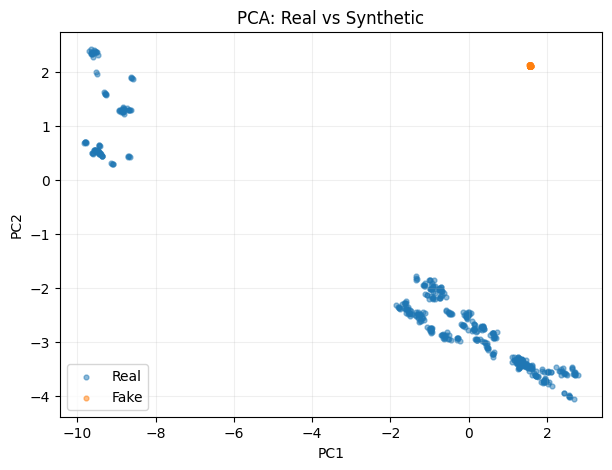

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Load real and synthetic data
X_real = X_train_gan if 'X_train_gan' in globals() else np.load(output_dir / 'timegan_splits_augmented.npz', allow_pickle=True)['X_train']
X_fake = x_synth if 'x_synth' in globals() else np.load(output_dir / 'timegan_synthetic_augmented.npz', allow_pickle=True)['X_synth']

print('Real shape:', X_real.shape)
print('Fake shape:', X_fake.shape)

# Align sample count for fair comparison
n = min(X_real.shape[0], X_fake.shape[0])
Xr = X_real[:n]
Xf = X_fake[:n]

# Flatten over sequences and time
R = Xr.reshape(-1, Xr.shape[-1])
F = Xf.reshape(-1, Xf.shape[-1])

# 1) Mean / Std comparison
feature_names = FEATURE_COLUMNS if 'FEATURE_COLUMNS' in globals() else [f'f{i}' for i in range(Xr.shape[-1])]
rows = []
for i, name in enumerate(feature_names):
    r_mean, f_mean = R[:, i].mean(), F[:, i].mean()
    r_std, f_std = R[:, i].std(), F[:, i].std()
    rows.append({
        'feature': name,
        'real_mean': r_mean,
        'fake_mean': f_mean,
        'abs_mean_diff': abs(r_mean - f_mean),
        'real_std': r_std,
        'fake_std': f_std,
        'abs_std_diff': abs(r_std - f_std),
    })
stat_df = pd.DataFrame(rows)

# 2) KS test (distribution check)
ks_rows = []
max_points = min(120000, R.shape[0], F.shape[0])
idx_r = np.random.default_rng(42).choice(R.shape[0], size=max_points, replace=False)
idx_f = np.random.default_rng(43).choice(F.shape[0], size=max_points, replace=False)
for i, name in enumerate(feature_names):
    ks_stat, ks_p = ks_2samp(R[idx_r, i], F[idx_f, i])
    ks_rows.append({'feature': name, 'ks_stat': ks_stat, 'ks_pvalue': ks_p})
ks_df = pd.DataFrame(ks_rows)

# 3) Temporal check via lag-1 autocorrelation

def lag1_autocorr(x):
    x0 = x[:-1]
    x1 = x[1:]
    denom = (x0.std() * x1.std()) + 1e-8
    return float(((x0 - x0.mean()) * (x1 - x1.mean())).mean() / denom)

ac_rows = []
for i, name in enumerate(feature_names):
    ac_real = np.mean([lag1_autocorr(seq[:, i]) for seq in Xr])
    ac_fake = np.mean([lag1_autocorr(seq[:, i]) for seq in Xf])
    ac_rows.append({'feature': name, 'ac_real_lag1': ac_real, 'ac_fake_lag1': ac_fake, 'abs_diff': abs(ac_real - ac_fake)})
ac_df = pd.DataFrame(ac_rows)

# 4) Discriminative score (real-vs-fake classifier)
# Accuracy near 0.5 means fake is harder to distinguish.
X_disc_real = Xr.reshape(n, -1)
X_disc_fake = Xf.reshape(n, -1)
X_disc = np.vstack([X_disc_real, X_disc_fake])
y_disc = np.hstack([np.ones(n), np.zeros(n)])

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_disc, y_disc, test_size=0.3, random_state=42, stratify=y_disc
)
clf = LogisticRegression(max_iter=1000, n_jobs=None)
clf.fit(X_train_d, y_train_d)
acc = accuracy_score(y_test_d, clf.predict(X_test_d))

# Print summaries
print('\n=== Mean/Std Difference (lower is better) ===')
print(stat_df[['feature', 'abs_mean_diff', 'abs_std_diff']])
print('Avg abs_mean_diff:', stat_df['abs_mean_diff'].mean())
print('Avg abs_std_diff:', stat_df['abs_std_diff'].mean())

print('\n=== KS Test (lower ks_stat is better) ===')
print(ks_df)
print('Avg ks_stat:', ks_df['ks_stat'].mean())

print('\n=== Lag-1 Autocorrelation Difference (lower is better) ===')
print(ac_df[['feature', 'ac_real_lag1', 'ac_fake_lag1', 'abs_diff']])
print('Avg ac abs_diff:', ac_df['abs_diff'].mean())

print('\n=== Discriminative Score ===')
print(f'Real-vs-fake accuracy: {acc:.4f} (target ~0.5)')

# 5) PCA visualization
pca_n = min(500, n)
pca_real = Xr[:pca_n].reshape(pca_n, -1)
pca_fake = Xf[:pca_n].reshape(pca_n, -1)
X_pca = np.vstack([pca_real, pca_fake])
labels = np.array(['Real'] * pca_n + ['Fake'] * pca_n)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_pca)

plt.figure(figsize=(7, 5))
plt.scatter(Z[labels == 'Real', 0], Z[labels == 'Real', 1], s=12, alpha=0.5, label='Real')
plt.scatter(Z[labels == 'Fake', 0], Z[labels == 'Fake', 1], s=12, alpha=0.5, label='Fake')
plt.title('PCA: Real vs Synthetic')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()